## Step 0


In [5]:
import pandas as pd
import numpy as np  # All the libraries that we need are in this section
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter



In [6]:
df_raw = pd.read_csv("data/symbol_info_3-25.csv")

df = df_raw[
    (df_raw["is_etf"] == 0)&
    (df_raw["is_fund"] == 0)&
    (df_raw["is_actively_trading"] == 1)&  # Make a copy of the original dataset imposing 
    (df_raw["market_cap"] > 0) &          # the conditions given at step 0
    (df_raw["total_revenue"] > 0) &
    (df_raw["sector"] == 'Financial Services')
].copy()



df["market_cap_b"] = df["market_cap"] / 1e9   # Changing the scale of the variables  
df["revenue_b"] = df["total_revenue"] / 1e9 
df = df.replace([np.inf, -np.inf], np.nan)

plt.rcParams["axes.titleweight"] = "bold"


In [7]:
def billions_formatter(x, pos):
    return f"{x:,.0f}B"      # This is usefull for the axis in our graphs
                             # to have the right format    

def billions_formatter_str(x):
    return f"{x:,.1f}B"   

def clean_spines(ax):
    ax.spines["top"].set_visible(False)      # This is usefull to delete 
    ax.spines["right"].set_visible(False)    # useless corners
    return ax


## Step 1

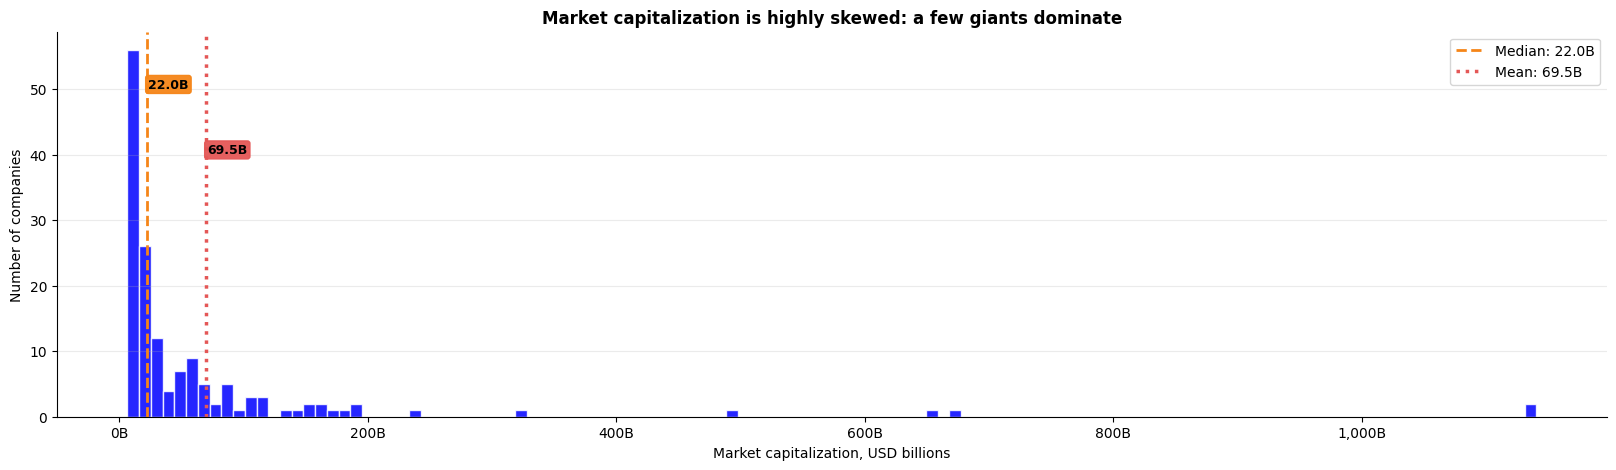

In [8]:
market_cap_b = df["market_cap_b"].dropna() # First we drop NA values

fig, ax = plt.subplots(figsize=(20, 5))

ax.hist(
    market_cap_b,          
    bins=120,                 # Histogram creation with its properties
    color="#0000FF",     
    edgecolor="white",  
    alpha=0.85          
    )

median_value = market_cap_b.median()    # Here I evaluate the median and the mean
mean_value = market_cap_b.mean()

ax.axvline(median_value, color="#F58518", linestyle="--", linewidth=2, label=f"Median: {median_value:,.1f}B")   # Here we rappresent the median and the mean
ax.axvline(mean_value, color="#E45756", linestyle=":", linewidth=2.5, label=f"Mean: {mean_value:,.1f}B")        # as a vertical line on the plot

ax.annotate(
        billions_formatter_str(mean_value),               # The annotate for ax it's usefull to insert o the plot a text with 
        (mean_value,40),                                  # the value to see better on the plot the values of mean and median
        xytext=(1, 1),
        textcoords="offset points",
        fontsize=9,
        weight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="#E45756",
            ec="#E45756",
            alpha=0.95
        )
)

ax.annotate(
        billions_formatter_str(median_value),
        (median_value,50),
        xytext=(1, 1),
        textcoords="offset points",
        fontsize=9,
        weight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="#F58518",
            ec="#F58518",
            alpha=0.95
        )
)



ax.set_title("Market capitalization is highly skewed: a few giants dominate")
ax.set_xlabel("Market capitalization, USD billions")                           # Here we set te title, the axis lable, the grid and the legend
ax.set_ylabel("Number of companies")                                           # in this case we erase the corners that are usless in this plot with clean_spines function
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="y", alpha=0.25)
ax.legend()
clean_spines(ax)

plt.show()



## Step 2

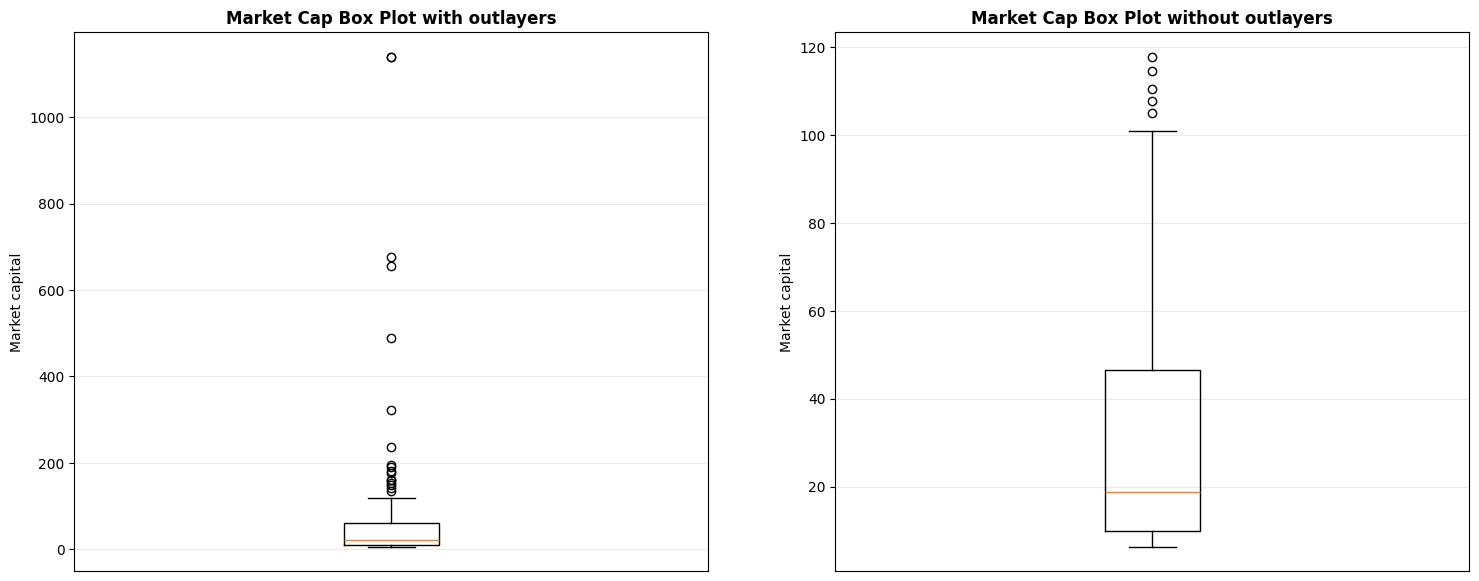

In [9]:
t_quantile = market_cap_b.quantile(0.75)
f_quantile = market_cap_b.quantile(0.25)
out = t_quantile+1.5*(t_quantile-f_quantile)

market_cap_b_wo = market_cap_b[market_cap_b< out] # We took only the values that are less then the third + 1.5IQR
                                        

fig, axes = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize=(18, 7)
)

ax_mc = axes[0]
ax_mcwo = axes[1]
ax_mc.boxplot(market_cap_b)
ax_mc.set_title("Market Cap Box Plot with outlayers")
ax_mc.set_ylabel("Market capital")
ax_mc.set_xticks([])
ax_mc.grid(axis="y",alpha=0.25)

ax_mcwo.boxplot(market_cap_b_wo)
ax_mcwo.set_title("Market Cap Box Plot without outlayers")
ax_mcwo.set_ylabel("Market capital")
ax_mcwo.set_xticks([])
ax_mcwo.grid(axis="y",alpha=0.25)


## Step 3


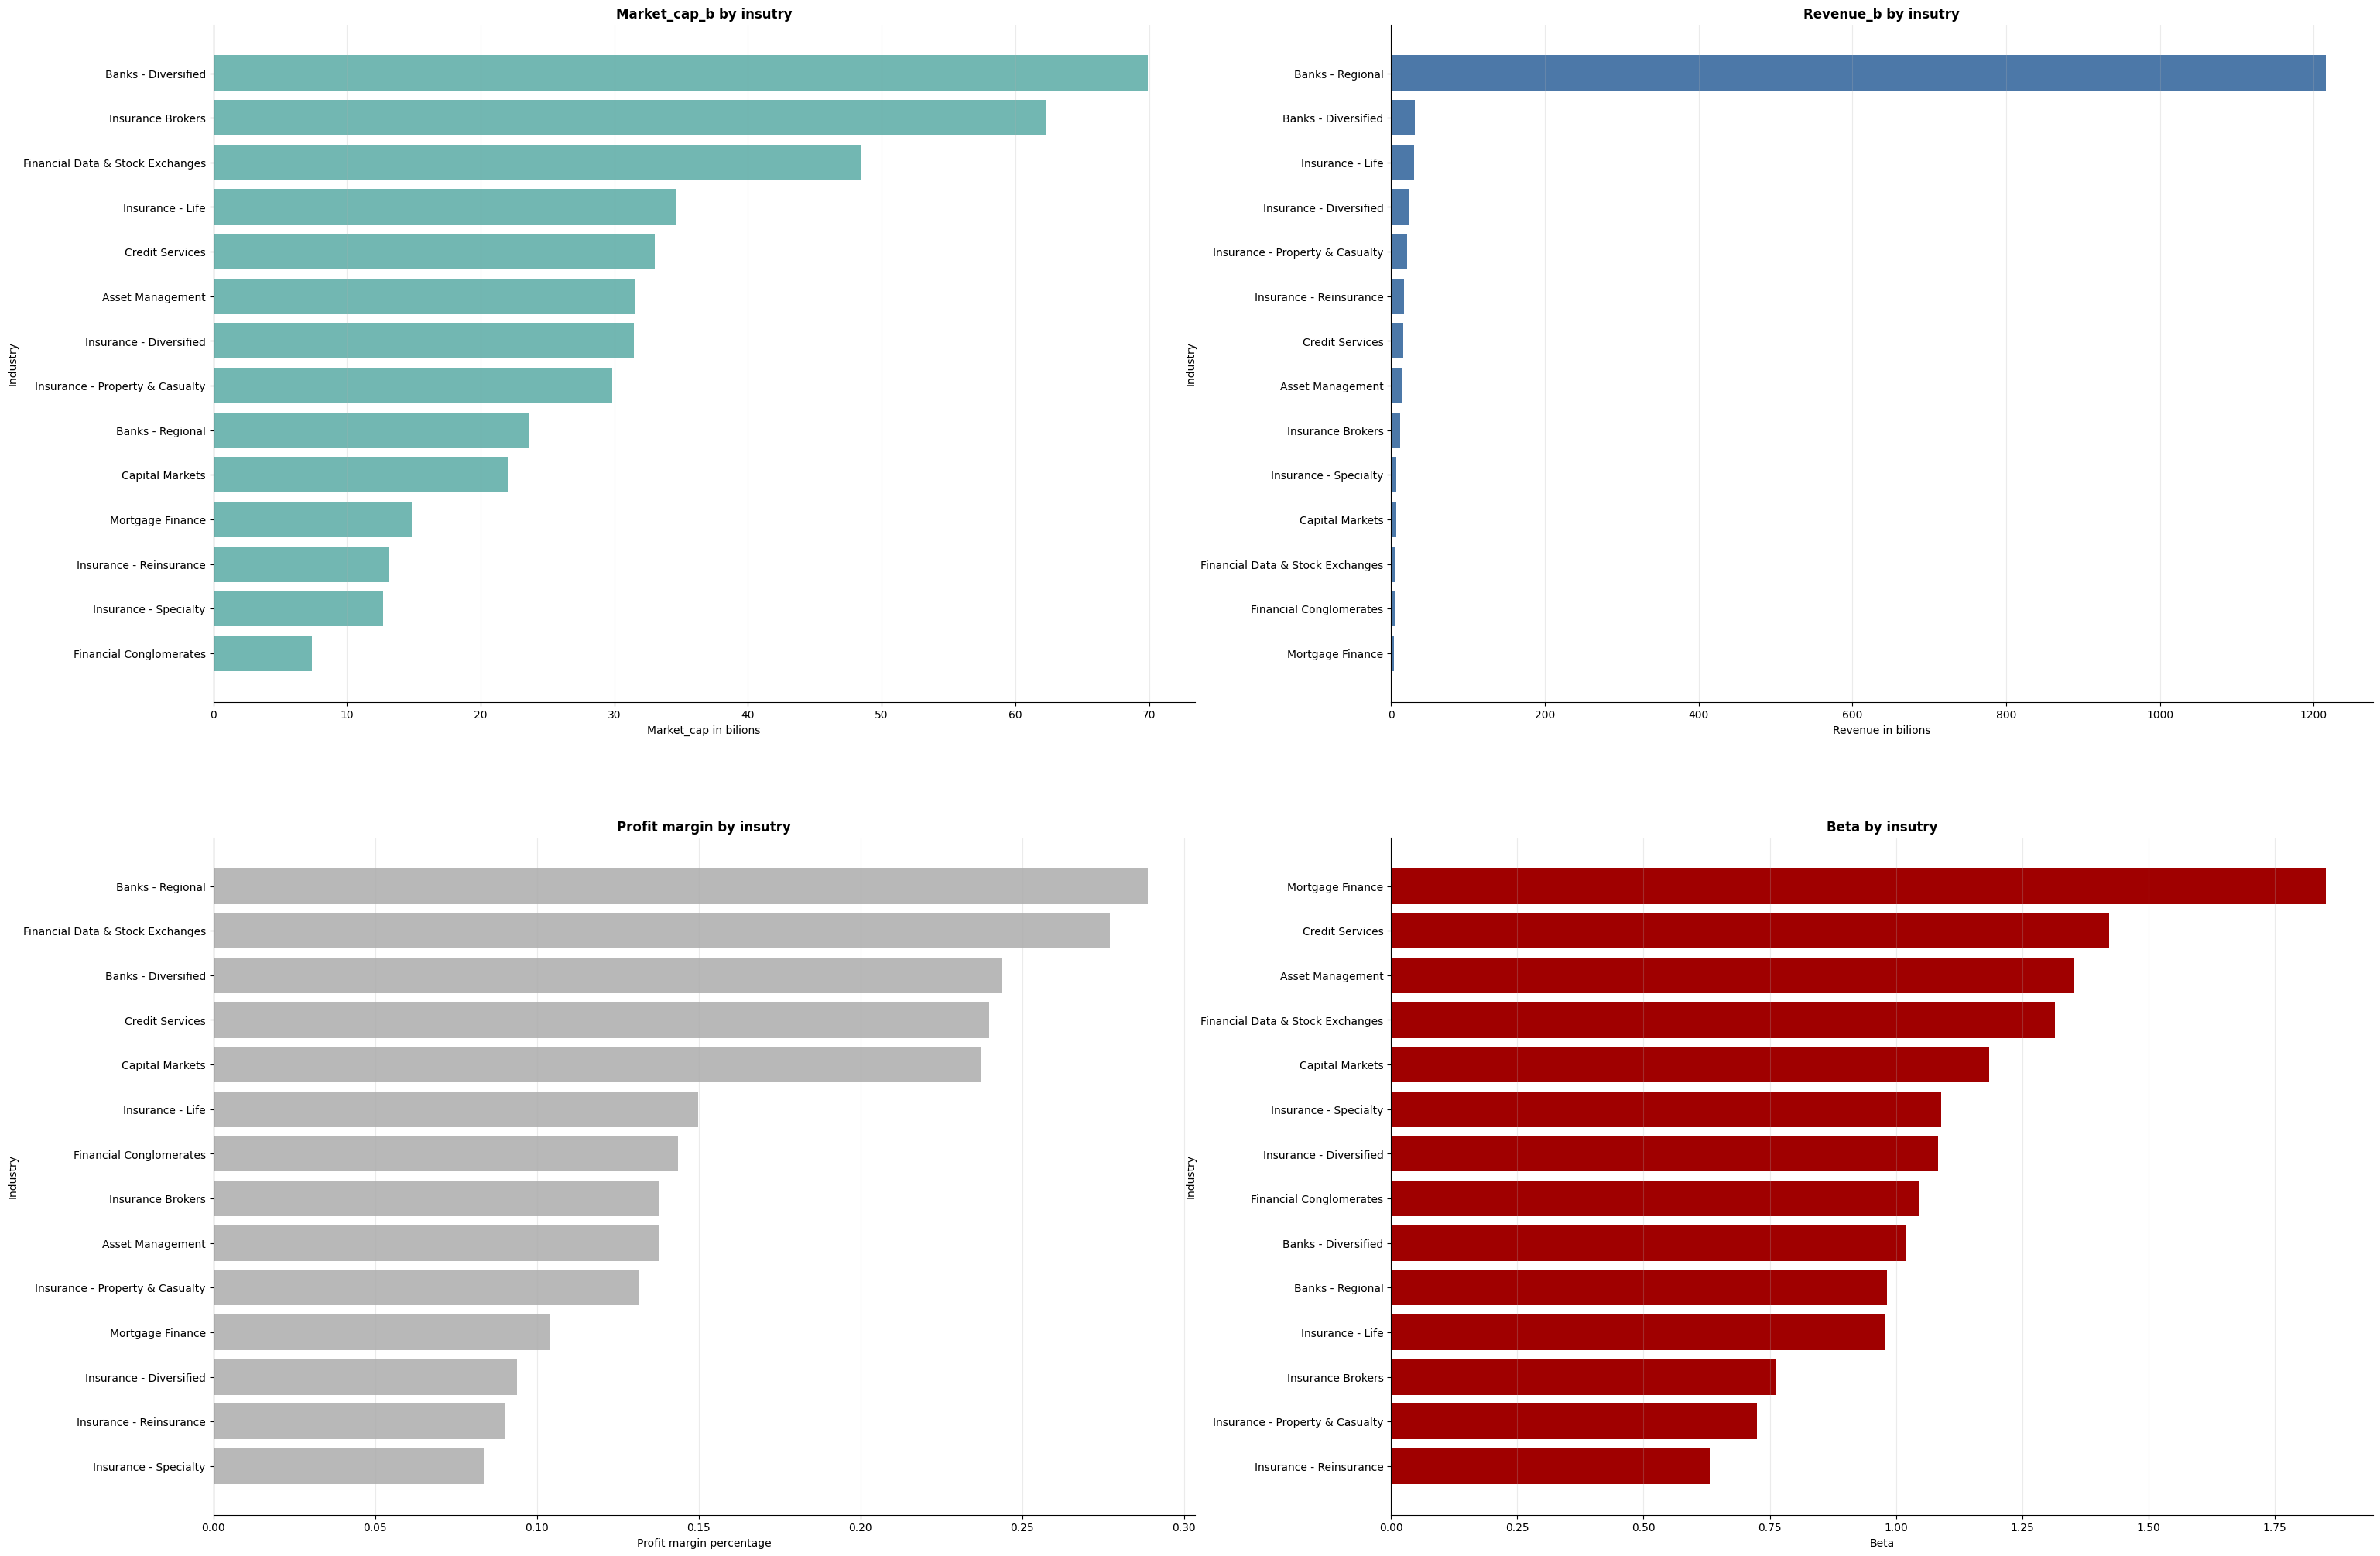

In [50]:
df_industry = df[df["market_cap_b"]< out].copy() # taking only the values without the outlayers
                                        # in market_cap
df_industry["industry_clean"] = df_industry["industry"].fillna("Unknow") # Changing the NA in sector with Unknow


# We create a new dataframe grouped by industry and with the 4 features that are requested in the step
industry_summary = (df_industry
                    .groupby("industry_clean")
                    .agg(
                        mean_market_cap = ("market_cap_b","mean"),
                        mean_total_revenue = ("revenue_b","mean"),
                        mean_profit_margin = ("profit_margins","mean"),
                        mean_beta = ("beta","mean")
                        ))


fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize = (36,25)
)

ax_market = axes[0,0]
ax_revenue = axes[0,1]
ax_profit_margin = axes[1,0]
ax_beta = axes[1,1]

# Crating each barh with their sorting 
ax_market.barh(
    industry_summary.sort_values("mean_market_cap",ascending=True).index,
    industry_summary["mean_market_cap"].sort_values(ascending=True),
    color="#72B7B2"
)
ax_market.set_title("Market_cap_b by insutry")
ax_market.set_xlabel("Market_cap in bilions")
ax_market.set_ylabel("Industry")
clean_spines(ax_market)
ax_market.grid(axis="x",alpha = 0.25)


ax_revenue.barh(
    industry_summary.sort_values("mean_total_revenue",ascending=True).index,
    industry_summary["mean_total_revenue"].sort_values(ascending=True),
    color="#4C78A8"
)
ax_revenue.set_title("Revenue_b by insutry")
ax_revenue.set_xlabel("Revenue in bilions")
ax_revenue.set_ylabel("Industry")
clean_spines(ax_revenue)
ax_revenue.grid(axis="x",alpha = 0.25)


ax_profit_margin.barh(
    industry_summary.sort_values("mean_profit_margin",ascending=True).index,
    industry_summary["mean_profit_margin"].sort_values(ascending=True),
    color="#b8b8b8"
)
ax_profit_margin.set_title("Profit margin by insutry")
ax_profit_margin.set_xlabel("Profit margin percentage")
ax_profit_margin.set_ylabel("Industry")
clean_spines(ax_profit_margin)
ax_profit_margin.grid(axis="x",alpha = 0.25)

ax_beta.barh(
    industry_summary.sort_values("mean_beta",ascending=True).index,
    industry_summary["mean_beta"].sort_values(ascending=True),
    color="#a00000"
)
ax_beta.set_title("Beta by insutry")
ax_beta.set_xlabel("Beta")
ax_beta.set_ylabel("Industry")
clean_spines(ax_beta)
ax_beta.grid(axis="x",alpha = 0.25)


## Step 4


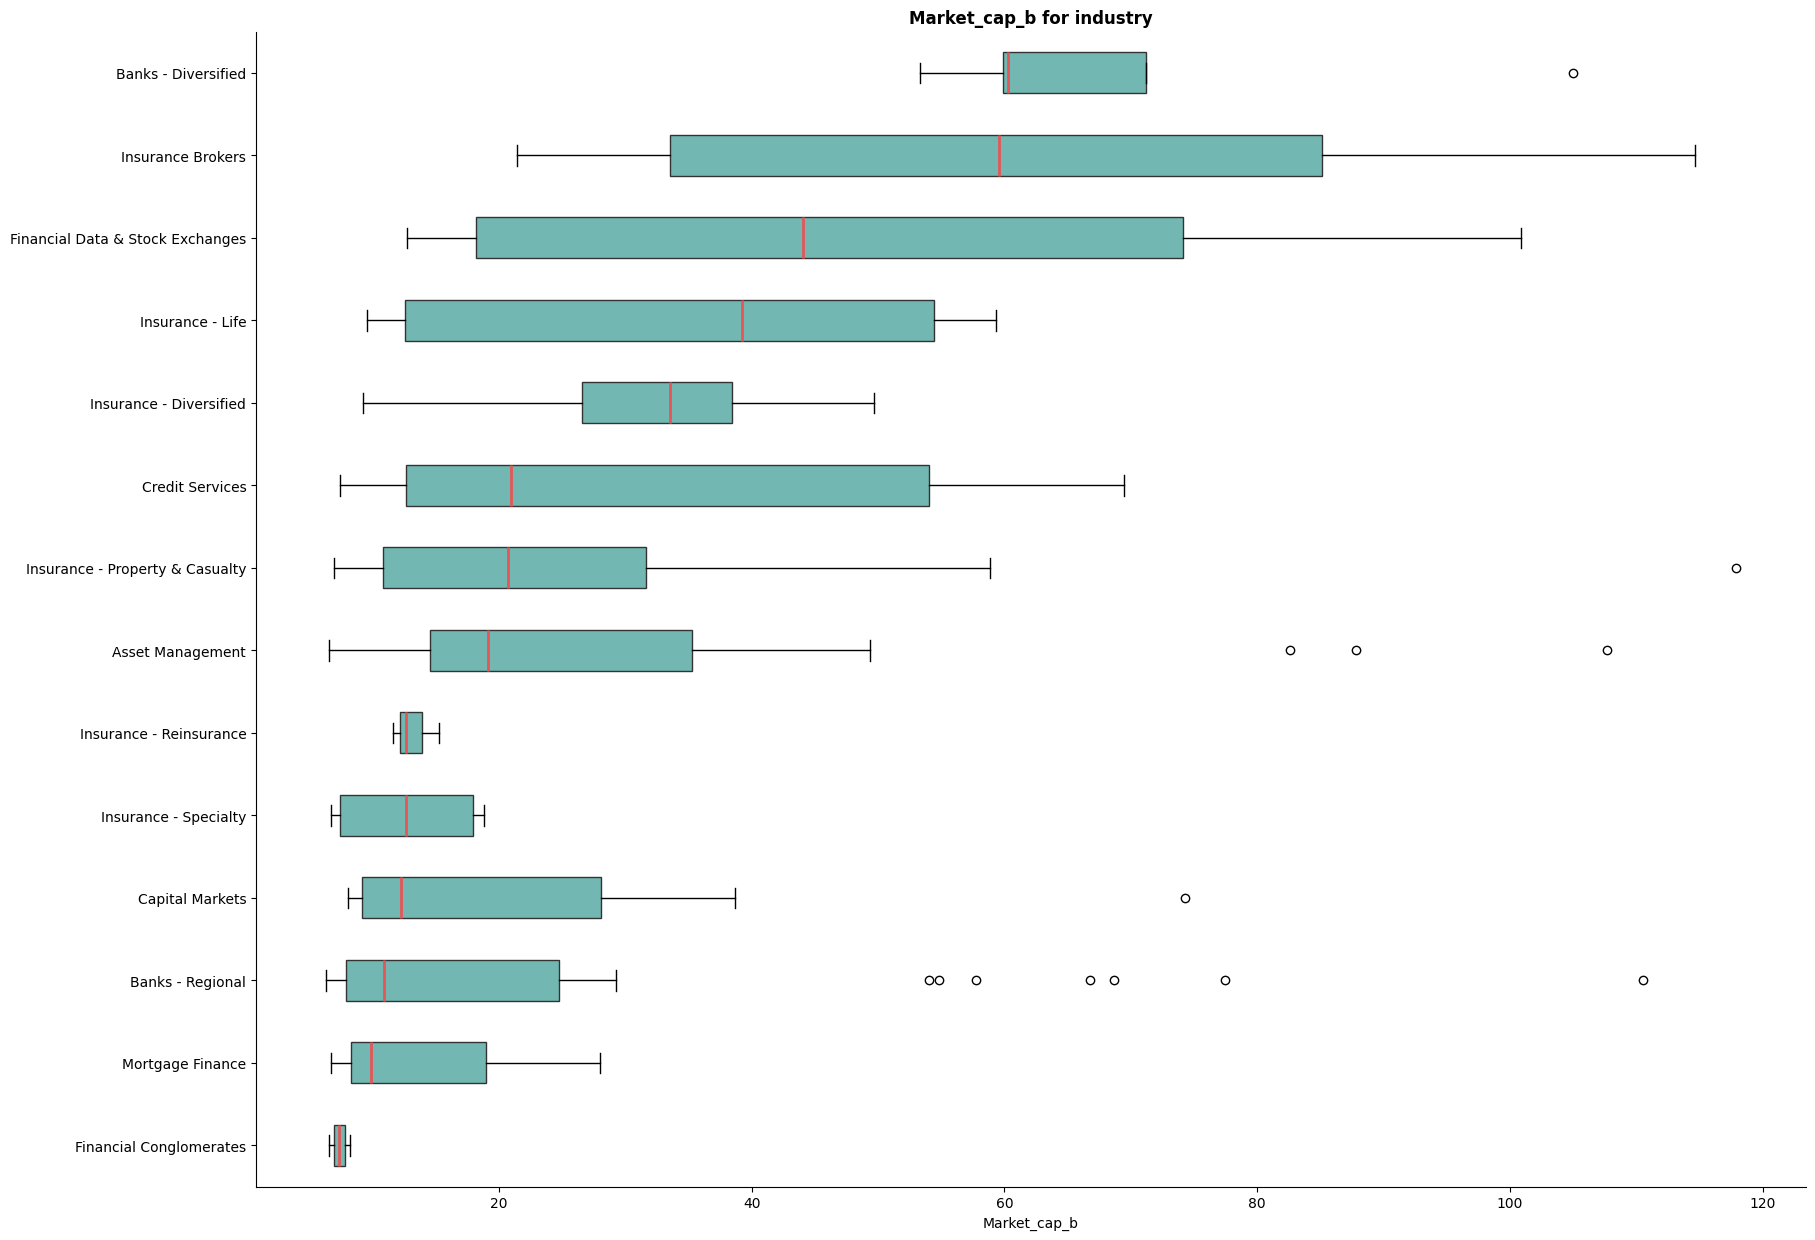

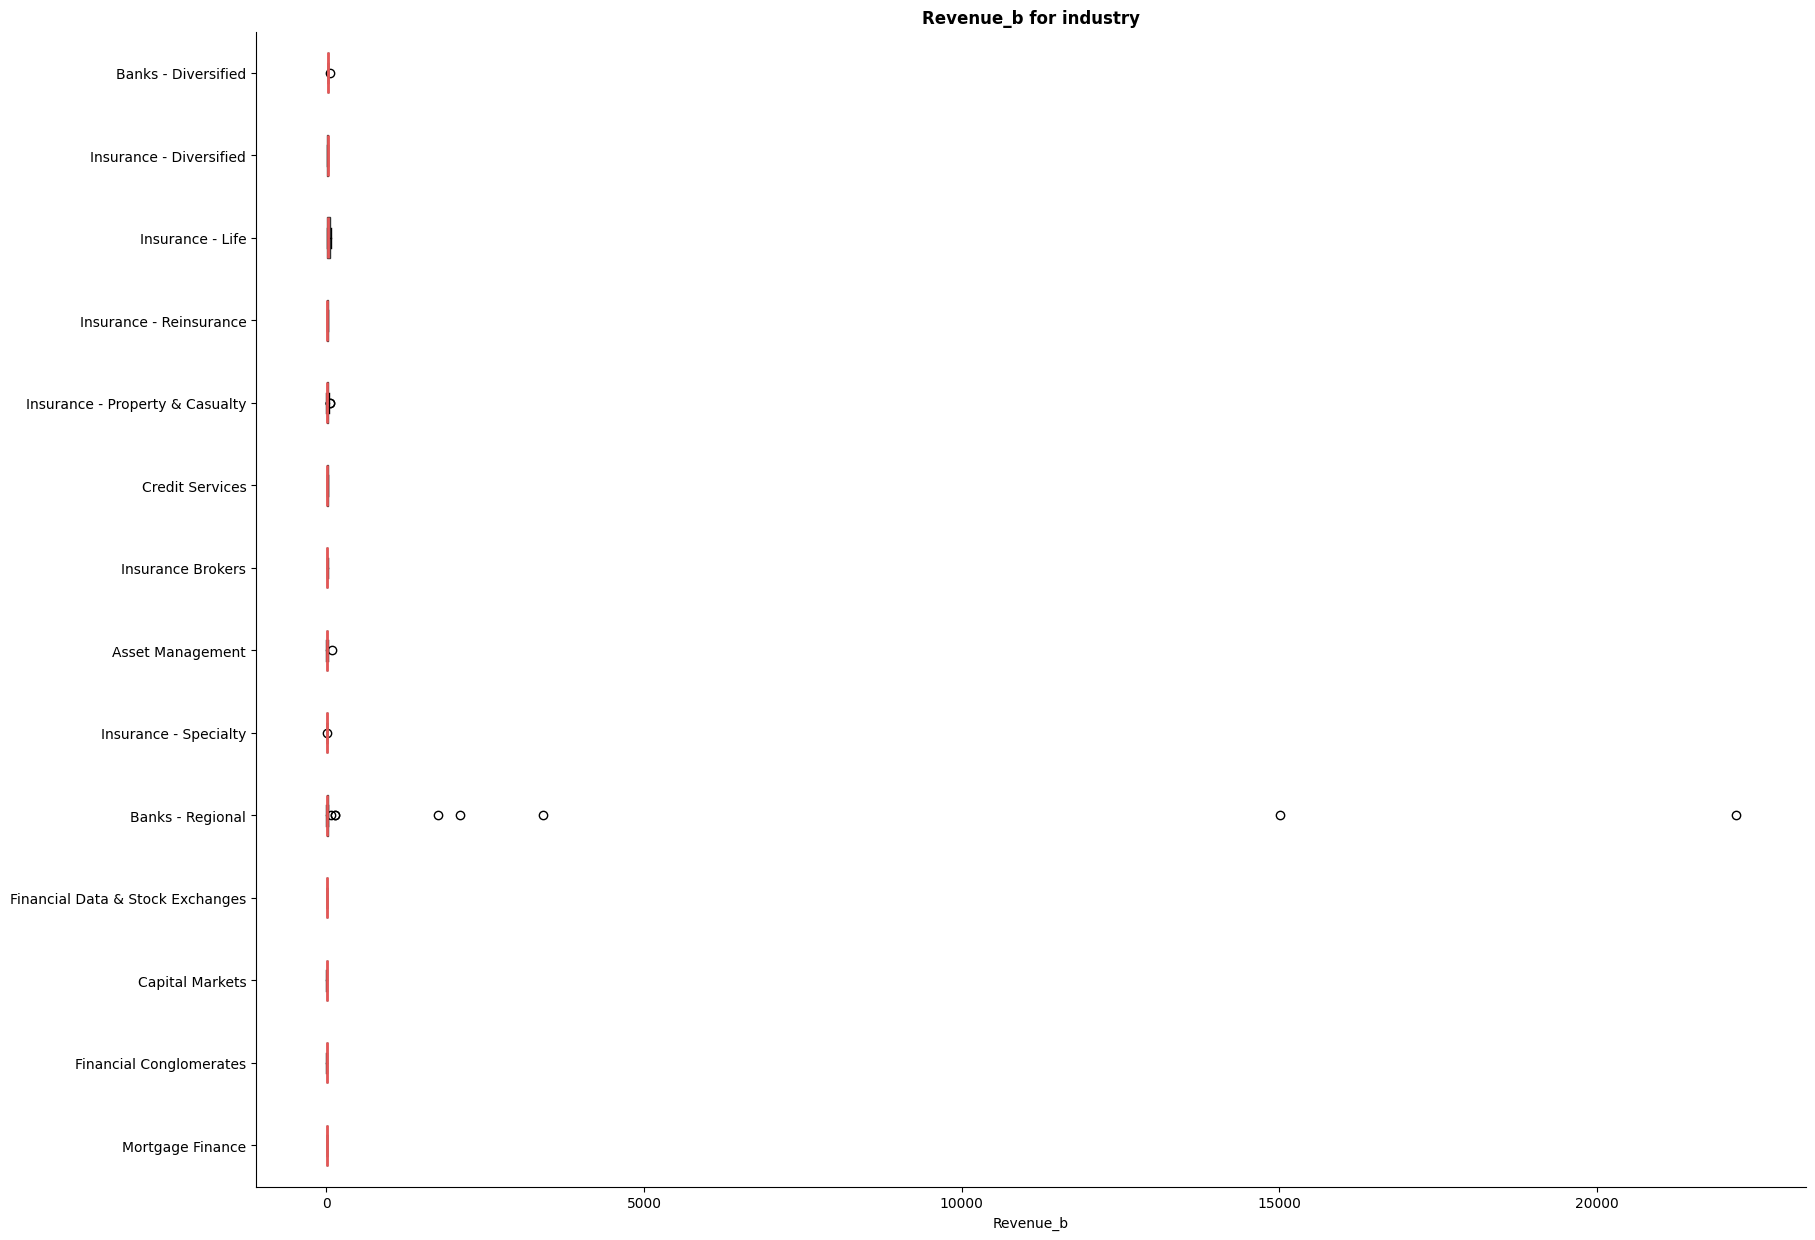

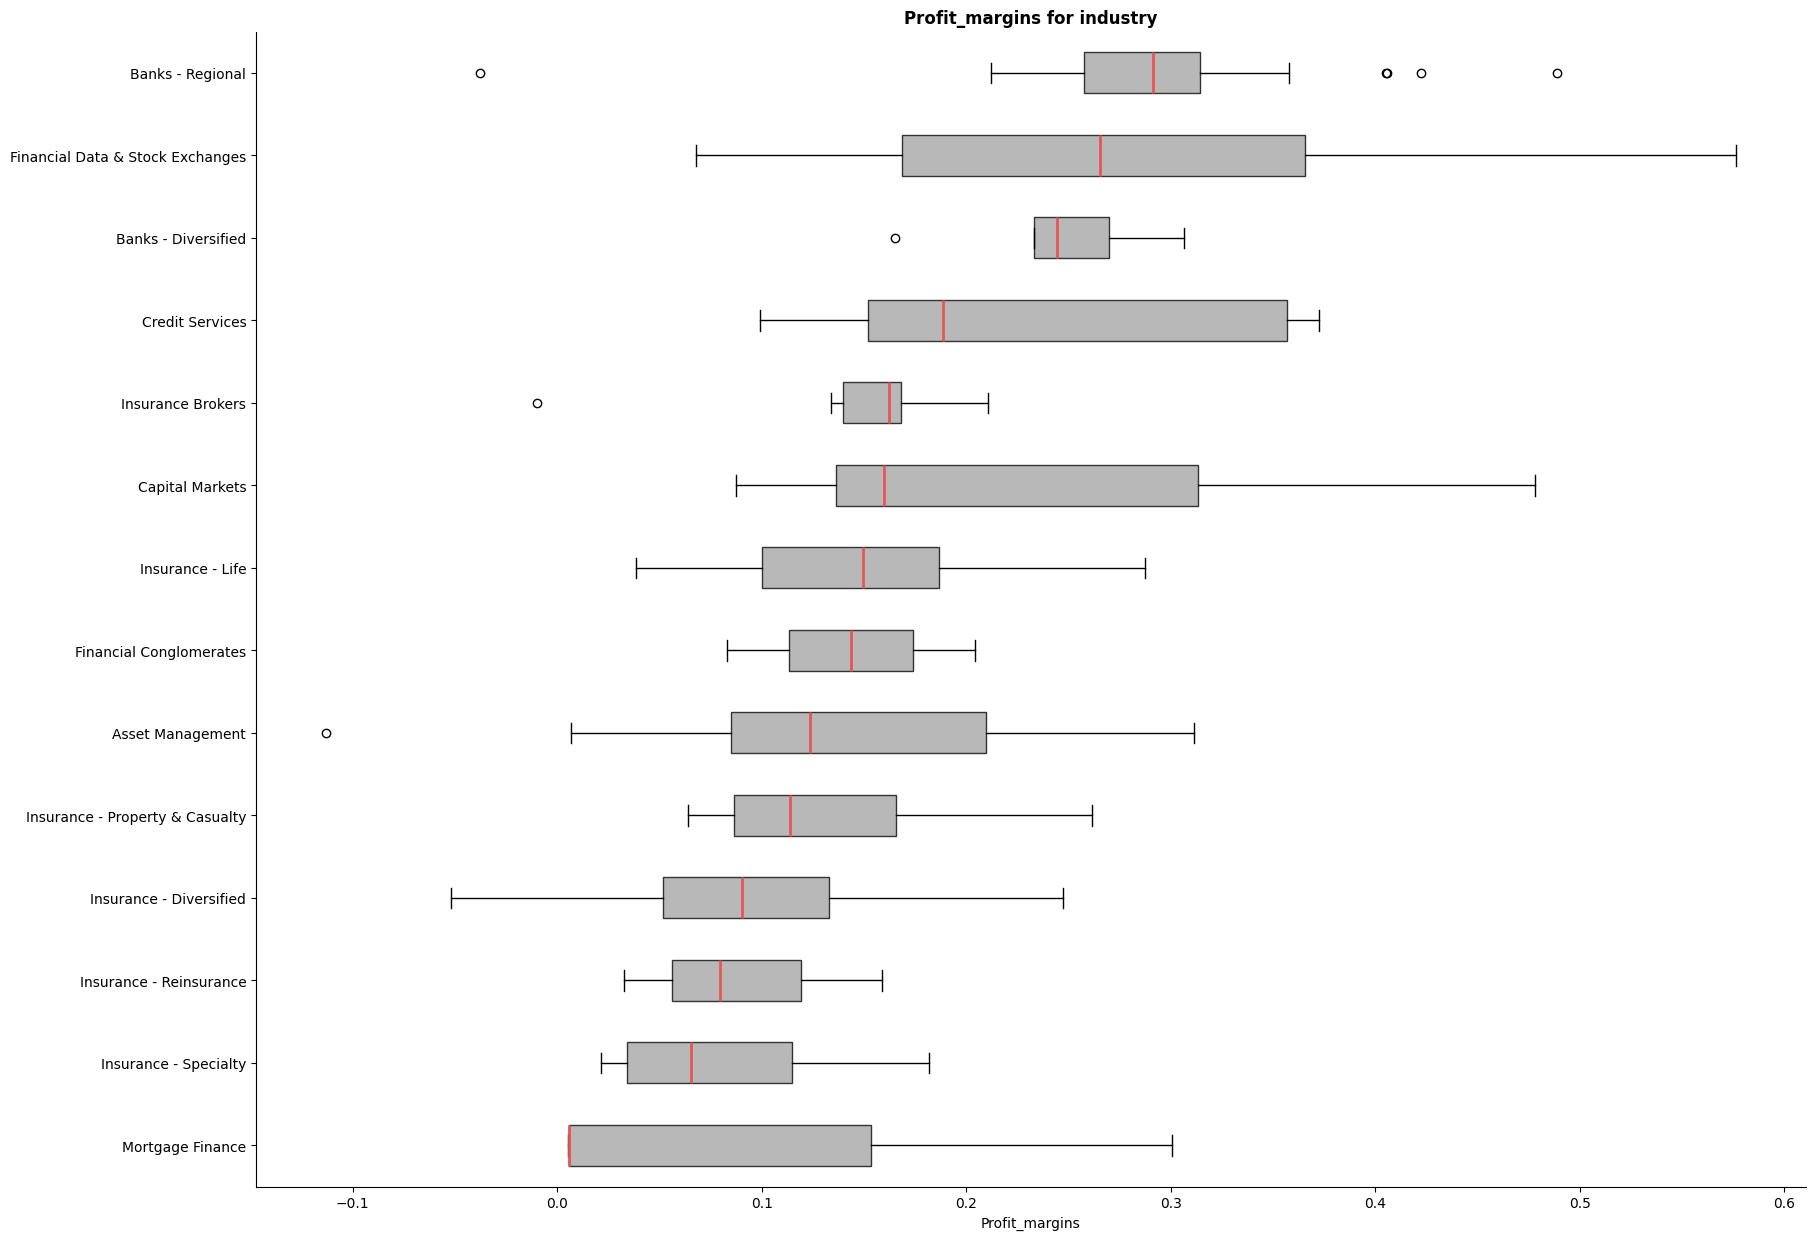

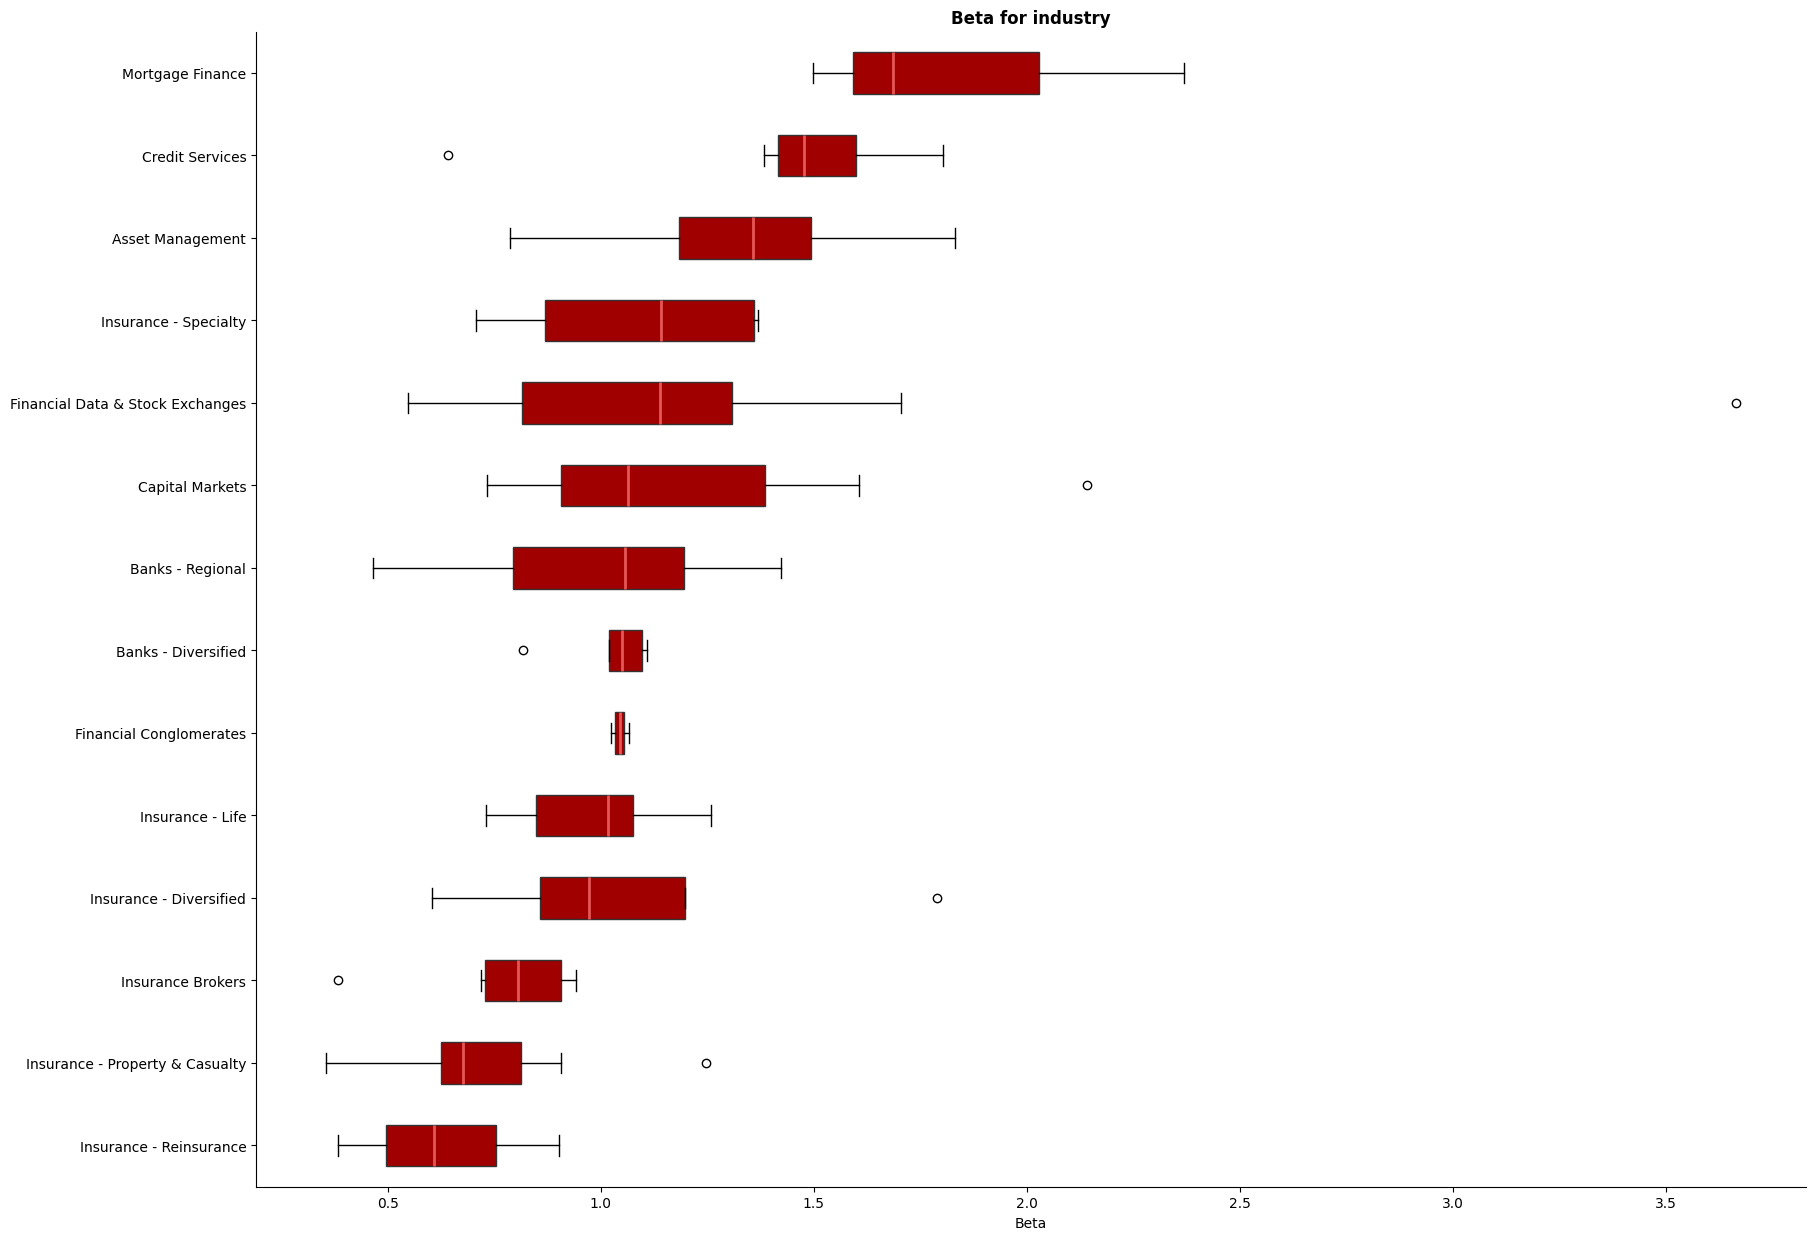

In [43]:
# For each attributes I create a sorted list of industry ordered by the 
# median of each atribute
industry = {"market_cap_b": 0,
            "revenue_b":0,
            "profit_margins":0,
            "beta":0
}

colors = {"market_cap_b": "#72B7B2",
          "revenue_b":"#4C78A8",
          "profit_margins":"#b8b8b8",
          "beta":"#a00000"
}


for att in industry.keys():
    industry[att] = (df_industry
            .groupby("industry_clean")[att] # we add to the industry dictionary each list of industries
            .median()                       # ordered by the median for each attribute
            .sort_values(ascending=True)
            .index)
    
box_data = {"market_cap_b":0,
            "revenue_b":0,
            "profit_margins":0,
            "beta":0} 

for key in box_data.keys():
      box_data[key] = [df_industry.loc[df_industry["industry_clean"] == ind ,key].values for ind in industry[key]] # Here we add to the dictionary a list of elements for each attributes
      fig, ax = plt.subplots(figsize = (20,15))                                                                    # for each industry this becuase boxplot need a list of list to plot 
      ax.boxplot(                                                                                                  # different boxplots in the same graph. All is ordered by the median
           box_data[key],
           tick_labels = industry[key],
           vert = False,
           patch_artist=True,                                               # Here we create our boxplots 
           boxprops={"facecolor": colors[key], "edgecolor": "#333333"},
           medianprops={"color": "#E45756", "linewidth": 2}
      )
      ax.set_title(key.capitalize()+" for industry")
      ax.set_xlabel(key.capitalize())
      clean_spines(ax)



## Step 5

In [83]:
# To have a bettere comparison between industry i will take the top 3 industries in revenue. This because banks-regional has 
# revenues to much higher compered to ones of other industries and this can lead to big outlayers in the next steps.

best_ind = industry_summary.sort_values("mean_total_revenue", ascending = False).nlargest(n=4,columns="mean_total_revenue").index
best_ind = best_ind[1:]

df_top3 = df_industry[(df_industry["industry_clean"] == best_ind[0]) |
                      (df_industry["industry_clean"] == best_ind[1]) |
                      (df_industry["industry_clean"] == best_ind[2])
                      ].copy()


## Step 6